In [1]:
import pandas as pd
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt

In [2]:
connection = mysql.connector.connect(
    host = 'localhost',
    user = 'root',
    password = 'root@123',
    database = 'fintech_risk_analytics'
)

print("Database connected successfully!")

Database connected successfully!


In [3]:
customers = pd.read_sql(
    "SELECT * FROM customers",
    connection
)

customers.head()

C:\Users\Shambhu\AppData\Local\Temp\ipykernel_21128\2258803360.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql(


,customer_id,first_name,last_name,gender,date_of_birth,city,state,employment_type,monthly_income,signup_date
0,1,Larry,Keith,Female,1987-12-15,East Megan,Illinois,Freelancer,62011.0,2024-10-31
1,2,Jill,Bell,Female,1986-12-16,Buchananmouth,South Carolina,Bussiness,76108.0,2023-08-29
2,3,Nancy,Peters,Female,1972-04-02,Jessicamouth,Tennessee,Self-Employed,150282.0,2025-04-10
3,4,Alicia,Thompson,Female,2000-01-18,Lake James,Arizona,Salaried,142116.0,2025-01-01
4,5,Brenda,Simmons,Female,1986-05-10,New Danny,Delaware,Bussiness,91268.0,2024-10-17


In [101]:
loans = pd.read_sql(
    "SELECT * FROM loans",
    connection
)

loans.head()

C:\Users\Shambhu\AppData\Local\Temp\ipykernel_21128\293642920.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  loans = pd.read_sql(


,loan_id,customer_id,loan_amount,interest_rate,tenure_months,loan_status,disbursement_date
0,1,6930,487521.0,21.72,48,Closed,2025-06-30
1,2,1842,983630.0,11.76,48,Closed,2025-04-05
2,3,1780,831941.0,19.20,36,Default,2025-09-01
3,4,6840,366026.0,19.64,36,Closed,2025-11-04
4,5,3810,116700.0,17.12,48,Active,2026-01-02


In [5]:
repayments = pd.read_sql(
    "SELECT * FROM repayments",
    connection
)

repayments.head()

C:\Users\Shambhu\AppData\Local\Temp\ipykernel_21128\2300041850.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  repayments = pd.read_sql(


,repayment_id,loan_id,due_date,payment_date,amount_paid,repayment_status
0,1,5508,2025-09-16,2026-04-20,9521.24,Missed
1,2,9144,2026-04-09,2025-09-22,18498.87,On-Time
2,3,1939,2026-03-12,2025-07-26,24573.49,Missed
3,4,6588,2025-09-02,2026-04-29,8339.99,Late
4,5,10102,2025-07-20,2025-11-26,36234.69,Late


In [7]:
transactions = pd.read_sql(
    "SELECT * FROM transactions",
    connection
)

transactions.head()

C:\Users\Shambhu\AppData\Local\Temp\ipykernel_21128\3142874628.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions = pd.read_sql(


,transaction_id,customer_id,transaction_date,transaction_type,merchant_category,amount
0,1,6264,2025-12-03,Card,Healthcare,18052.15
1,2,9441,2026-02-10,Card,Entertainment,16763.57
2,3,3371,2025-11-10,Bank Transfer,Healthcare,32027.13
3,4,3608,2025-07-27,UPI,Food,8787.62
4,5,8580,2025-09-30,UPI,Bills,48366.90


In [8]:
credit_scores = pd.read_sql(
    "SELECT * FROM credit_scores",
    connection
)

credit_scores.head()

C:\Users\Shambhu\AppData\Local\Temp\ipykernel_21128\4184473140.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  credit_scores = pd.read_sql(


,score_id,customer_id,credit_score,score_date


In [102]:
print(customers.shape)
print(loans.shape)
print(repayments.shape)
print(transactions.shape)
print(credit_scores.shape)

(10000, 10)
(15000, 7)
(20000, 6)
(50000, 6)
(0, 4)


In [11]:
print(customers.info())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      10000 non-null  int64  
 1   first_name       10000 non-null  str    
 2   last_name        10000 non-null  str    
 3   gender           10000 non-null  str    
 4   date_of_birth    10000 non-null  object 
 5   city             10000 non-null  str    
 6   state            10000 non-null  str    
 7   employment_type  10000 non-null  str    
 8   monthly_income   10000 non-null  float64
 9   signup_date      10000 non-null  object 
dtypes: float64(1), int64(1), object(2), str(6)
memory usage: 781.4+ KB
None


In [15]:
print(loans.info())

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   loan_id            15000 non-null  int64  
 1   customer_id        15000 non-null  int64  
 2   loan_amount        15000 non-null  float64
 3   interest_rate      15000 non-null  float64
 4   tenure_months      15000 non-null  int64  
 5   loan_status        15000 non-null  str    
 6   disbursement_date  15000 non-null  object 
dtypes: float64(2), int64(3), object(1), str(1)
memory usage: 820.4+ KB
None


In [16]:
print(repayments.info())

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   repayment_id      20000 non-null  int64  
 1   loan_id           20000 non-null  int64  
 2   due_date          20000 non-null  object 
 3   payment_date      20000 non-null  object 
 4   amount_paid       20000 non-null  float64
 5   repayment_status  20000 non-null  str    
dtypes: float64(1), int64(2), object(2), str(1)
memory usage: 937.6+ KB
None


In [17]:
print(transactions.info())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   transaction_id     50000 non-null  int64  
 1   customer_id        50000 non-null  int64  
 2   transaction_date   50000 non-null  object 
 3   transaction_type   50000 non-null  str    
 4   merchant_category  50000 non-null  str    
 5   amount             50000 non-null  float64
dtypes: float64(1), int64(2), object(1), str(2)
memory usage: 2.3+ MB
None


In [18]:
print(credit_scores.info())

<class 'pandas.DataFrame'>
RangeIndex: 0 entries
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   score_id      0 non-null      object
 1   customer_id   0 non-null      object
 2   credit_score  0 non-null      object
 3   score_date    0 non-null      object
dtypes: object(4)
memory usage: 132.0+ bytes
None


In [19]:
customers.isna().sum()

customer_id        0
first_name         0
last_name          0
gender             0
date_of_birth      0
city               0
state              0
employment_type    0
monthly_income     0
signup_date        0
dtype: int64

In [20]:
loans.isna().sum()

loan_id              0
customer_id          0
loan_amount          0
interest_rate        0
tenure_months        0
loan_status          0
disbursement_date    0
dtype: int64

In [21]:
repayments.isna().sum()

repayment_id        0
loan_id             0
due_date            0
payment_date        0
amount_paid         0
repayment_status    0
dtype: int64

In [22]:
transactions.isna().sum()

transaction_id       0
customer_id          0
transaction_date     0
transaction_type     0
merchant_category    0
amount               0
dtype: int64

In [23]:
credit_scores.isna().sum()

score_id        0
customer_id     0
credit_score    0
score_date      0
dtype: int64

In [24]:
loans.describe()

,loan_id,customer_id,loan_amount,interest_rate,tenure_months
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,5012.365200,528346.398000,16.018691,25.223600
std,4330.271354,2887.305417,274731.043371,4.597991,15.366227
min,1.000000,1.000000,50073.000000,8.000000,6.000000
25%,3750.750000,2508.000000,290788.750000,12.057500,12.000000
50%,7500.500000,5017.500000,531556.000000,16.050000,24.000000
75%,11250.250000,7513.000000,765309.750000,19.940000,36.000000
max,15000.000000,10000.000000,999982.000000,24.000000,48.000000


In [25]:
transactions.describe()

,transaction_id,customer_id,amount
count,50000.000000,50000.00000,50000.000000
mean,25000.500000,5010.04444,25147.428072
std,14433.901067,2891.11084,14324.455520
min,1.000000,1.00000,103.160000
25%,12500.750000,2504.75000,12763.580000
50%,25000.500000,5020.00000,25187.930000
75%,37500.250000,7511.00000,37525.317500
max,50000.000000,10000.00000,49996.740000


SECTION 1 — KPI ANALYSIS IN PANDAS

In [ ]:
#TOTAL LOAN AMOUNT
loans['loan_amount'].sum()

np.float64(7925195970.0)

In [27]:
#AVERAGE LOAN AMOUNT
loans['loan_amount'].mean()

np.float64(528346.398)

In [136]:
#loan risk
loans['loan_status'].value_counts()

loan_status
Default    5155
Active     4930
Closed     4915
Name: count, dtype: int64

## Loan Risk Insight

Most loans are currently active, while defaulted loans represent a smaller share of the portfolio, indicating moderate overall portfolio risk.

In [31]:
#DEFAULT RATE
(
    loans['loan_status']
    .value_counts(normalize=True) * 100
)

loan_status
Default    34.366667
Active     32.866667
Closed     32.766667
Name: proportion, dtype: float64

In [ ]:
#EMPLOYMENT TYPE DISTRIBUTION
customers['employment_type'].value_counts()

employment_type
Salaried         2575
Bussiness        2488
Freelancer       2476
Self-Employed    2461
Name: count, dtype: int64

SECTION 2 — CREATE VISUALIZATIONS 📊

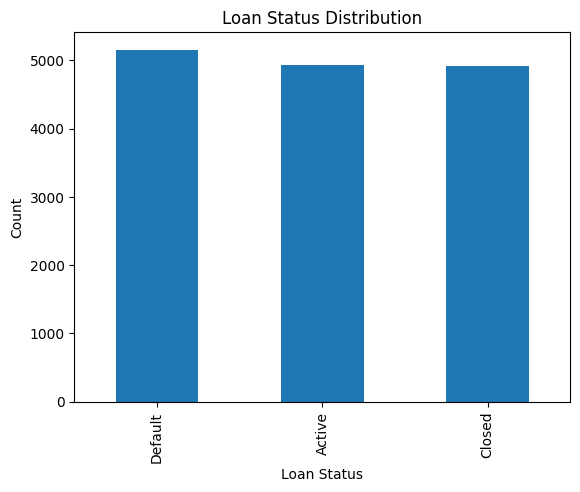

In [34]:
#LOAN STATUS CHART

loans['loan_status'].value_counts().plot(kind='bar')

plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

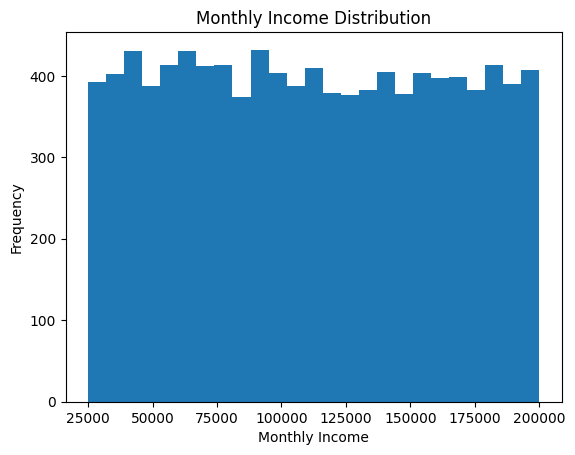

In [ ]:
#MONTHLY INCOME DISTRIBUTION using histogram
customers['monthly_income'].plot(kind='hist', bins=25)
plt.title('Monthly Income Distribution')
plt.xlabel('Monthly Income')
plt.ylabel('Frequency')
plt.show()


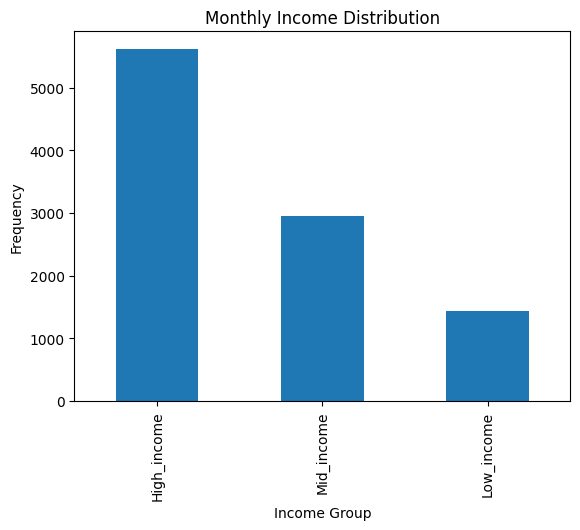

In [ ]:
###MONTHLY INCOME DISTRIBUTION using bar chart
grouped_income = np.where(customers['monthly_income'] < 50000, 'Low_income',
                 np.where(customers['monthly_income'] < 100000, 'Mid_income',
                 'High_income'
                 )
                 )  
pd.Series(grouped_income).value_counts().plot(kind='bar')
plt.title('Monthly Income Distribution')
plt.xlabel('Income Group')
plt.ylabel('Frequency')
plt.show()

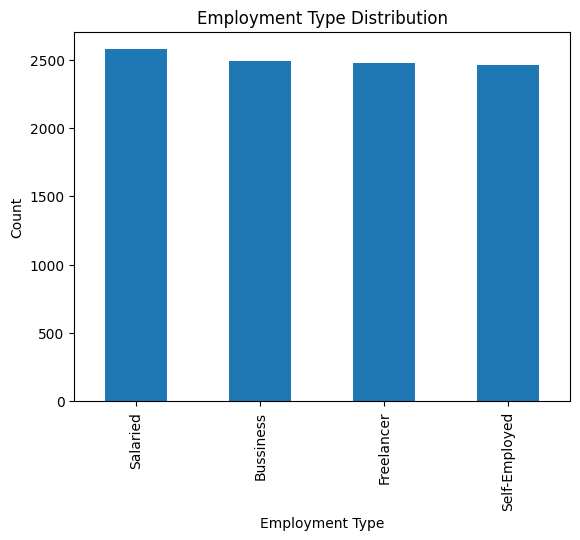

In [17]:
#EMPLOYMENT TYPE BAR CHART
customers['employment_type'].value_counts().plot(kind='bar')
plt.title('Employment Type Distribution')
plt.xlabel('Employment Type')
plt.ylabel('Count')
plt.show()

SECTION 3 — CREATE MERGED ANALYTICS DATASET

In [18]:
#MERGE CUSTOMERS + LOANS

customers_loans = pd.merge(customers, loans, on='customer_id')
print(customers_loans.head())

   customer_id first_name last_name  gender date_of_birth               city  \
0            1      Larry     Keith  Female    1987-12-15         East Megan   
1            1      Larry     Keith  Female    1987-12-15         East Megan   
2            1      Larry     Keith  Female    1987-12-15         East Megan   
3            3      Nancy    Peters  Female    1972-04-02       Jessicamouth   
4            7      Barry   Estrada    Male    1976-06-05  Port Kennethburgh   

       state employment_type  monthly_income signup_date  loan_id  \
0   Illinois      Freelancer         62011.0  2024-10-31     3529   
1   Illinois      Freelancer         62011.0  2024-10-31     5269   
2   Illinois      Freelancer         62011.0  2024-10-31     6550   
3  Tennessee   Self-Employed        150282.0  2025-04-10      618   
4    Arizona      Freelancer         93363.0  2025-03-01     6280   

   loan_amount  interest_rate  tenure_months loan_status disbursement_date  
0     421688.0          12.

In [135]:
#loan status by loan amount

loans.groupby('loan_status')['loan_amount'].mean().round(2)

loan_status
Active     528547.42
Closed     525266.47
Default    531090.69
Name: loan_amount, dtype: float64

In [9]:
# monthly_income distribution

grouped_income = np.where(customers['monthly_income'] < 50000, 'Low_income',
                 np.where(customers['monthly_income'] < 100000, 'Mid_income',
                 'High_income'
                 )
                 )  
pd.Series(grouped_income).value_counts()

High_income    5613
Mid_income     2950
Low_income     1437
Name: count, dtype: int64

In [ ]:
#high valued customers

customers_loans = pd.merge(customers, loans, on='customer_id')
customers_loans.groupby(['customer_id','first_name','last_name'])['loan_amount'].sum().sort_values(ascending=False).head(10)

customer_id  first_name  last_name
3569         Nathaniel   Strong       4660964.0
7561         Steven      Johnson      4618457.0
5244         David       Miller       4553113.0
8607         Theresa     Lee          4484699.0
2354         Shelby      Hernandez    4112368.0
5779         Bethany     Gonzalez     4031868.0
404          James       Knight       3976458.0
2770         Wendy       Allen        3969356.0
188          Jennifer    Allen        3964429.0
9183         Whitney     Carlson      3928905.0
Name: loan_amount, dtype: float64

In [37]:
#Missed Payment Risk Analysis
customers_loans_repayments = pd.merge(customers_loans, repayments, on='loan_id')
missed_payments = customers_loans_repayments[
    customers_loans_repayments['repayment_status'] == 'Missed'
]
missed_payments.groupby(['customer_id','first_name','last_name'])['repayment_status'].count().sort_values(ascending=False).head(10)

customer_id  first_name  last_name
5455         Aaron       Chavez       7
1611         April       Charles      6
3183         Julia       Pham         6
2871         Anthony     Smith        6
278          Maria       Herrera      6
600          Larry       Webb         6
3829         Lindsey     Howell       5
7408         Stephen     Williams     5
8044         Michael     Parker       5
3902         Janet       Brandt       5
Name: repayment_status, dtype: int64

In [79]:
#rank customer by loan amount using transform
loans['loan_rank'] = loans['loan_amount'].rank(method='min', ascending=False)
loans.sort_values(by='loan_rank').head()

,loan_id,customer_id,loan_amount,interest_rate,tenure_months,loan_status,disbursement_date,loan_rank
5378,5379,1309,999982.0,19.82,24,Active,2025-09-24,1.0
7192,7193,4322,999917.0,20.82,12,Closed,2025-12-21,2.0
11777,11778,9560,999842.0,13.17,48,Active,2025-12-28,3.0
12372,12373,3447,999789.0,16.99,36,Active,2024-12-07,4.0
4464,4465,3266,999754.0,16.66,12,Closed,2025-10-31,5.0


In [112]:
#running total of loan amount
sorted_loans = loans.sort_values(by='loan_amount', ascending=True).head()
sorted_loans['running_total'] = sorted_loans['loan_amount'].cumsum()
print(sorted_loans[['loan_id','customer_id', 'loan_amount', 'running_total']])

       loan_id  customer_id  loan_amount  running_total
3061      3062         2383      50073.0        50073.0
8122      8123         3478      50078.0       100151.0
12977    12978         4077      50079.0       150230.0
7343      7344         8116      50117.0       200347.0
10883    10884         6324      50156.0       250503.0


loans.head()

In [ ]:
#risk analysis based on transaction amount
total_transaction_count = transactions.groupby('customer_id').agg(
    total_transactions=('amount', 'count'),
    total_amount=('amount', 'sum')
)

total_transaction_count['risk_level'] = np.where(
    total_transaction_count['total_amount'] < 100000,
    'low_risk',
    'high_risk'
)

high_value_customers = (
    total_transaction_count[
        total_transaction_count['total_amount'] > 100000
    ]
    .sort_values(by='total_amount', ascending=False)
)

high_value_customers.head()

,total_transactions,total_amount,risk_level
customer_id,,,
9500,11,444204.15,high_risk
9938,13,420884.52,high_risk
1642,12,408096.32,high_risk
6904,12,407379.41,high_risk
1596,13,401513.87,high_risk


In [137]:
#INCOME VS LOAN
customers_loans.groupby('employment_type')['loan_amount'].mean().round(2)

employment_type
Bussiness        534952.73
Freelancer       522849.79
Salaried         526689.71
Self-Employed    529003.14
Name: loan_amount, dtype: float64

In [ ]:
#Which group gets larger loans?
'''employment_type
Bussiness        534952.73
Freelancer       522849.79
Salaried         526689.71
Self-Employed    529003.14'''

#Which group gets larger loans?
#  bussiness
#Which customers are trusted more?
#  salaried and self-employed
#why?
#  salaried and self-employed have more stable income compared to bussiness and freelancer

In [145]:
#CUSTOMER SEGMENTATION
customers_loans = pd.merge(customers, loans, on='customer_id')
customers_loans['income_range'] = np.where(
    customers_loans['monthly_income'] < 50000, 'Low_income',
    np.where(customers_loans['monthly_income'] < 100000, 'Mid_income', 'High_income')
)
customers_loans.groupby('income_range')['loan_amount'].mean().round(2)

income_range
High_income    529410.55
Low_income     540589.19
Mid_income     520284.95
Name: loan_amount, dtype: float64